# Инициализация

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

In [31]:
data = pd.read_csv('asteroids.csv')

# Исследование исходного датасета

### Датасет содержит поля:
- **id** - уникальный идентификатор объекта в базе данных
- **name** - название астероида (постоянное или временное)
- **est_diameter_min** - минимальный предполагаемый диаметр объекта (в километрах)
- **est_diameter_max** - максимальный предполагаемый диаметр объекта (в километрах)
- **relative_velocity** - скорость движения астероида относительно Земли на момент сближения (в км/ч)
- **miss_distance** - дистанция пролета, т.е. минимальное расстояние от Земли (в километрах)
- **absolute_magnitude** - абсолютная звездная величина
- **hazardous** - опасность объекта в формате True/False


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90266 non-null  float64
 1   name                90790 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90379 non-null  float64
 4   relative_velocity   90279 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   absolute_magnitude  90152 non-null  float64
 7   hazardous           90836 non-null  bool   
dtypes: bool(1), float64(6), object(1)
memory usage: 4.9+ MB


In [33]:
data.head(20)

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,3561024.0,(2011 GZ2),0.016016,0.035813,56014.078517,1.024333e+06,26.10,False
1,54016766.0,(2020 HT6),0.030518,0.068240,7864.348060,3.268186e+07,24.70,False
2,3746620.0,(2016 ED156),0.055533,0.124177,55257.544508,6.538636e+07,23.40,False
3,3633054.0,(2013 FD8),0.019256,0.043057,41531.404722,1.260796e+07,25.70,False
4,3742124.0,(2016 CW31),0.139494,0.311918,67639.394481,7.130590e+07,21.40,False
5,3395961.0,(2007 WU3),0.046191,0.103286,18933.875801,2.847083e+07,23.80,False
6,3826808.0,(2018 PH22),0.116026,0.259442,43184.402732,3.418417e+07,21.80,False
7,3339667.0,(2006 QV89),0.021113,0.047211,38064.802287,2.653154e+07,25.50,False
8,3644044.0,(2013 LL31),0.221083,0.494356,33736.859964,5.670662e+07,20.40,False
9,3655750.0,(2014 AC16),0.242412,0.542051,56188.215588,6.175441e+07,20.20,False


In [34]:
data.duplicated().sum()

0

In [35]:
true_hazardous_count = data[data['hazardous'] == True].shape[0]
false_hazardous_count = data[data['hazardous'] == False].shape[0]
(true_hazardous_count/data.shape[0] * 100, false_hazardous_count/data.shape[0] * 100)

(9.731824386806993, 90.26817561319301)

### Вывод некоторых первичных наблюдений:
- Столбцы **id**, **name**, **est_diameter_max**, **relative_velocity**, **absolute_magnitude** имеют пропуски
- Столбец **id** может быть использован для заполнения пропусков в данных, после чего должен быть удален, чтобы избежать возможного переобучения 
- Столбец **name** тоже может быть использован для заполнения пропусков, после чего постоянное имя должно быть удалено, т.к. не содержит существенной информации, а из временного имени (в скобках) может быть извлечена информация о периоде обнаружения, после чего врмененное имя следует удалить
- Cтолбец **hazardous** должен быть переведет с типа bool в тип int
- Присутствует умеренный дисбаланс классов (соотношение 1:9)


In [36]:
data.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.026600e+04,90836.000000,90379.000000,90279.000000,9.083600e+04,90152.000000
mean,1.438528e+07,0.127432,0.284911,48066.003701,3.706655e+07,23.526653
std,2.087357e+07,0.298511,0.668148,25294.523635,2.235204e+07,2.893982
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448595e+06,0.019256,0.043057,28620.469765,1.721082e+07,21.340000
50%,3.748364e+06,0.048368,0.108153,44190.108201,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62931.850541,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


Вывод из числовых характеристик:
- Большой разброс размеров, большинство объектов маленькие (до 320 метров), но есть и огромные. Данные сильно скошены
- Есть экстремальные выбросы по относительной скорости
- Распределение дистанции пролета довольно симметричное, медиана близка к среднему

# Обработка пропущенных значений

In [37]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

absolute_magnitude    0.753005
id                    0.627505
relative_velocity     0.613193
est_diameter_max      0.503104
name                  0.050641
est_diameter_min      0.000000
miss_distance         0.000000
hazardous             0.000000
dtype: float64

In [38]:
true_hazardous_with_NaN_count = data[data.isna().any(axis=1) & (data['hazardous'] == True)].shape[0]
NaN_count = data[data.isna().any(axis=1)].shape[0]

(true_hazardous_with_NaN_count/true_hazardous_count * 100, NaN_count/data.shape[0] * 100)


(2.760180995475113, 2.5276322163019067)

##### При удаленнии всех строк с пропусками теряем 2.76% опасных объектов и 2.53% всего датасета, что довольно мало, поэтому так и поступим

In [39]:
data = data.dropna().reset_index(drop=True)

# Проверим пропуски
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

id                    0.0
name                  0.0
est_diameter_min      0.0
est_diameter_max      0.0
relative_velocity     0.0
miss_distance         0.0
absolute_magnitude    0.0
hazardous             0.0
dtype: float64

# Коррекция типов и обогащение данных 

In [40]:
data['hazardous'] = data['hazardous'].astype(int)
data.head(20)

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,3561024.0,(2011 GZ2),0.016016,0.035813,56014.078517,1.024333e+06,26.10,0
1,54016766.0,(2020 HT6),0.030518,0.068240,7864.348060,3.268186e+07,24.70,0
2,3746620.0,(2016 ED156),0.055533,0.124177,55257.544508,6.538636e+07,23.40,0
3,3633054.0,(2013 FD8),0.019256,0.043057,41531.404722,1.260796e+07,25.70,0
4,3742124.0,(2016 CW31),0.139494,0.311918,67639.394481,7.130590e+07,21.40,0
5,3395961.0,(2007 WU3),0.046191,0.103286,18933.875801,2.847083e+07,23.80,0
6,3826808.0,(2018 PH22),0.116026,0.259442,43184.402732,3.418417e+07,21.80,0
7,3339667.0,(2006 QV89),0.021113,0.047211,38064.802287,2.653154e+07,25.50,0
8,3644044.0,(2013 LL31),0.221083,0.494356,33736.859964,5.670662e+07,20.40,0
9,3655750.0,(2014 AC16),0.242412,0.542051,56188.215588,6.175441e+07,20.20,0


Перевели столбец **hazardous** с типа bool в тип int

In [41]:
data['year'] = data['name'].str.extract(r'\((\d{4})')
data = data.drop(columns=['name'])

col = data.pop('year')
data.insert(1, 'year', col)

data.isna().sum()

id                    0
year                  6
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
absolute_magnitude    0
hazardous             0
dtype: int64

После извлечения года обнаружения из столбца **name** в столбце **year** оказалось 6 пропусков, удалим эти строки и переведем **year** в тип int

In [42]:
data = data.dropna().reset_index(drop=True)
data['year'] = data['year'].astype(int)
data.head(20)

,id,year,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,3561024.0,2011,0.016016,0.035813,56014.078517,1.024333e+06,26.10,0
1,54016766.0,2020,0.030518,0.068240,7864.348060,3.268186e+07,24.70,0
2,3746620.0,2016,0.055533,0.124177,55257.544508,6.538636e+07,23.40,0
3,3633054.0,2013,0.019256,0.043057,41531.404722,1.260796e+07,25.70,0
4,3742124.0,2016,0.139494,0.311918,67639.394481,7.130590e+07,21.40,0
5,3395961.0,2007,0.046191,0.103286,18933.875801,2.847083e+07,23.80,0
6,3826808.0,2018,0.116026,0.259442,43184.402732,3.418417e+07,21.80,0
7,3339667.0,2006,0.021113,0.047211,38064.802287,2.653154e+07,25.50,0
8,3644044.0,2013,0.221083,0.494356,33736.859964,5.670662e+07,20.40,0
9,3655750.0,2014,0.242412,0.542051,56188.215588,6.175441e+07,20.20,0


Также удалим столбец **id**

In [43]:
data = data.drop(columns=['id'])
data

,year,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,2011,0.016016,0.035813,56014.078517,1.024333e+06,26.10,0
1,2020,0.030518,0.068240,7864.348060,3.268186e+07,24.70,0
2,2016,0.055533,0.124177,55257.544508,6.538636e+07,23.40,0
3,2013,0.019256,0.043057,41531.404722,1.260796e+07,25.70,0
4,2016,0.139494,0.311918,67639.394481,7.130590e+07,21.40,0
...,...,...,...,...,...,...,...
88529,2021,0.017561,0.039268,23264.740825,1.635007e+06,25.90,0
88530,2018,0.110804,0.247765,24802.519406,3.351901e+07,21.90,0
88531,2016,0.035039,0.078350,116288.999548,5.471396e+07,24.40,0
88532,2014,0.044112,0.098637,45763.317060,2.694877e+07,23.90,0


### Проверка очищенных данных

In [44]:
data.duplicated().sum()

0

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88534 entries, 0 to 88533
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                88534 non-null  int32  
 1   est_diameter_min    88534 non-null  float64
 2   est_diameter_max    88534 non-null  float64
 3   relative_velocity   88534 non-null  float64
 4   miss_distance       88534 non-null  float64
 5   absolute_magnitude  88534 non-null  float64
 6   hazardous           88534 non-null  int32  
dtypes: float64(5), int32(2)
memory usage: 4.1 MB


In [46]:
data.head(20)

,year,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,2011,0.016016,0.035813,56014.078517,1.024333e+06,26.10,0
1,2020,0.030518,0.068240,7864.348060,3.268186e+07,24.70,0
2,2016,0.055533,0.124177,55257.544508,6.538636e+07,23.40,0
3,2013,0.019256,0.043057,41531.404722,1.260796e+07,25.70,0
4,2016,0.139494,0.311918,67639.394481,7.130590e+07,21.40,0
5,2007,0.046191,0.103286,18933.875801,2.847083e+07,23.80,0
6,2018,0.116026,0.259442,43184.402732,3.418417e+07,21.80,0
7,2006,0.021113,0.047211,38064.802287,2.653154e+07,25.50,0
8,2013,0.221083,0.494356,33736.859964,5.670662e+07,20.40,0
9,2014,0.242412,0.542051,56188.215588,6.175441e+07,20.20,0


# EDA

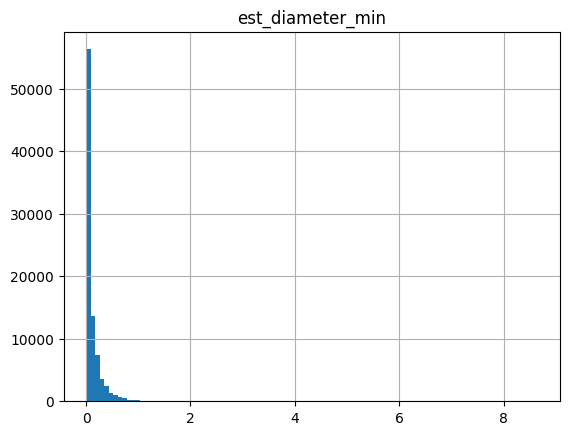

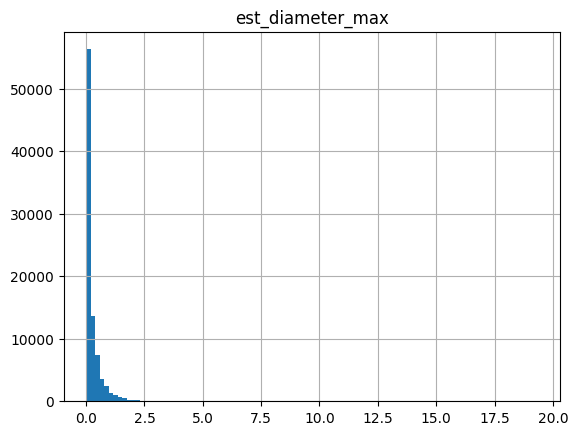

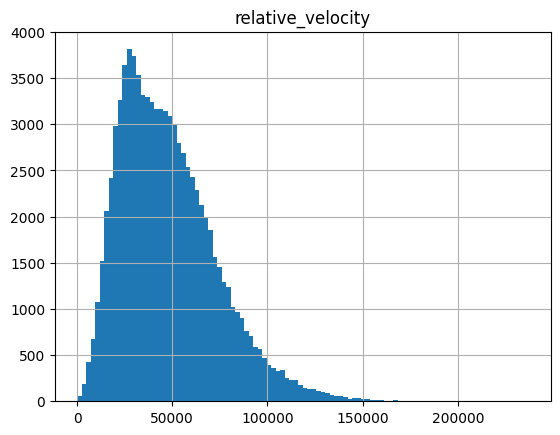

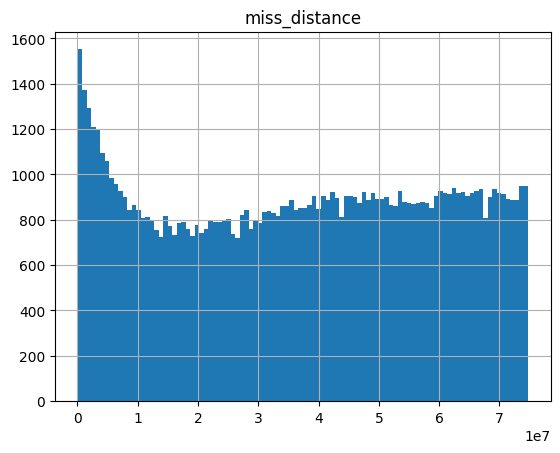

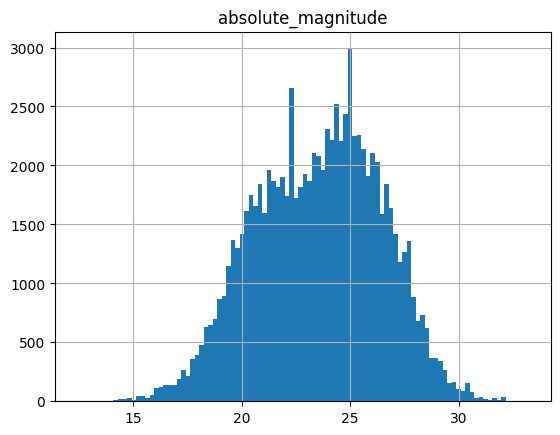

In [47]:
columns = ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

for column in columns:
    data.hist(column, bins=100)

Некоторые выводы из гистрограм:
- Распределения диаметров имеют очень сильную ассиметрию, подавляющее большинство объектов очень маленькие
- Огромное количество объектов зафиксировано на минимальном расстоянии от Земли
- **miss_distance** имеет почти равномерное распределение
- Есть четкий диапазон обычных скоростей и редкие сверхбыстрые объекты

Рассмотрим поближе гистограму диаматеров

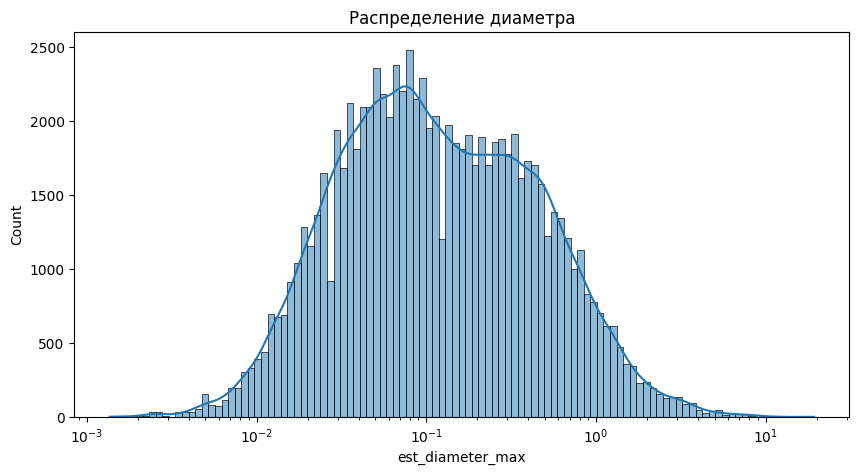

In [48]:
plt.figure(figsize=(10, 5))
# Логарифмируем масштаб оси х
sns.histplot(data['est_diameter_max'], kde=True, log_scale=True)
plt.title('Распределение диаметра')
plt.show()

Логарифмируем масштаб по оси х для того чтобы нагляднее посмотреть на распределение. Можно увидеть что оно бимодальное

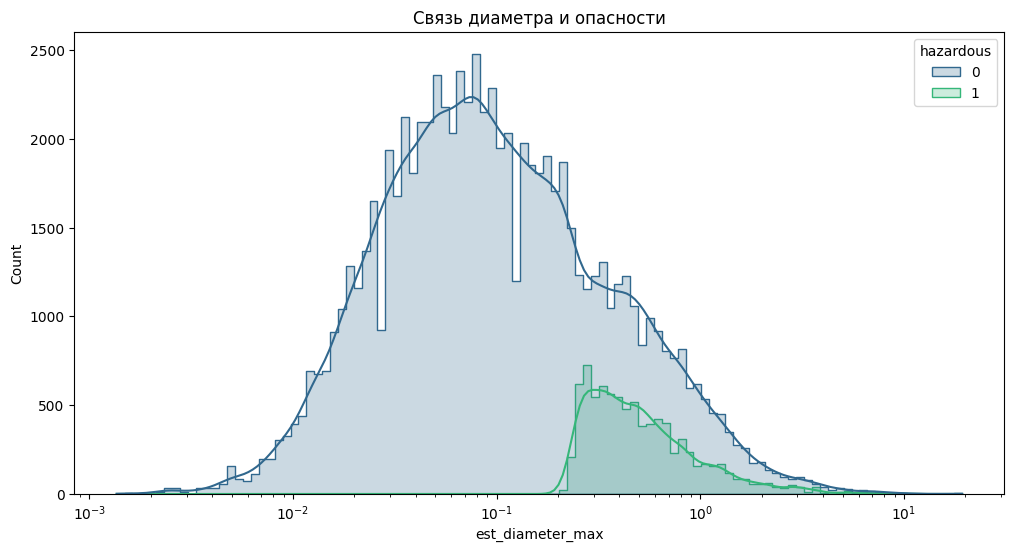

In [49]:
plt.figure(figsize=(12, 6))
# Добавляем hue='hazardous'
sns.histplot(data=data, x='est_diameter_max', hue='hazardous', 
             kde=True, log_scale=True, palette='viridis', element='step')
plt.title('Связь диаметра и опасности')
plt.show()


Можно увидеть, что зеленая область (опасные объекты) начинается очень резко, это значит что объекты меньше примерно 140 метров практически никогда не помечаются как опасные, значит если диаметр меньше этого порога, шанс на опасность объекта стремится к нулю.

Есть большие астероиды, которые не опасны, значит нужно посмотреть на признаки **miss_distance** и **relative_velocity**


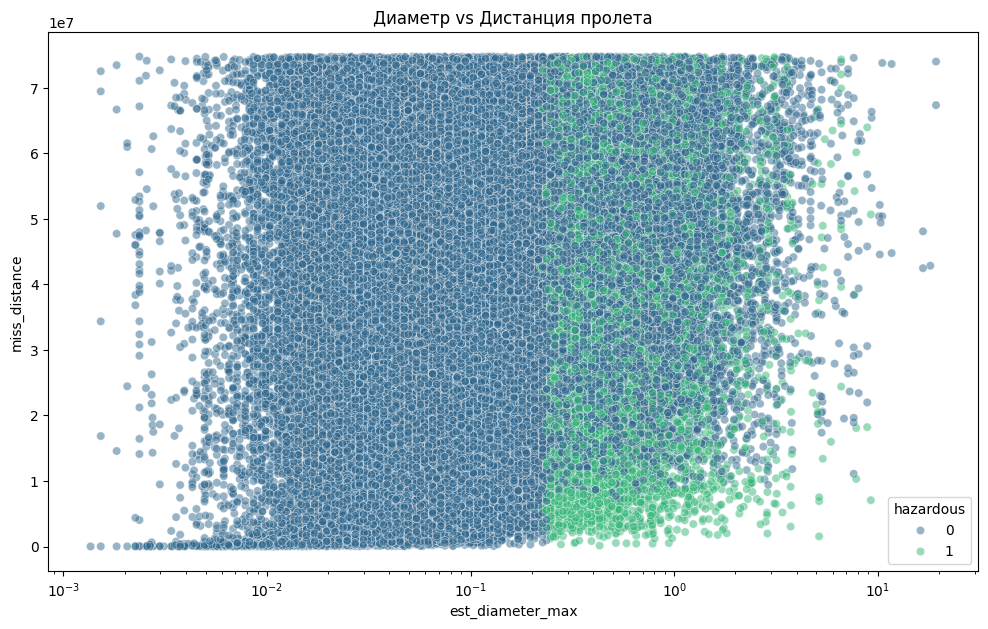

In [50]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=data, x='est_diameter_max', y='miss_distance', 
                hue='hazardous', alpha=0.5, palette='viridis')
plt.xscale('log') # Оставляем логарифмическую шкалу для диаметра
plt.title('Диаметр vs Дистанция пролета')
plt.show()

Видно четкую границу по оси X (диаметр), что значит что размер необходимое, но не достаточное условние опасности. 

Дистанция пролета тоже имеет корреляцию с опасностью (чем ближе тем опаснее), однако не такую сильную как размер

Выведем тепловую карту (Пирсон)

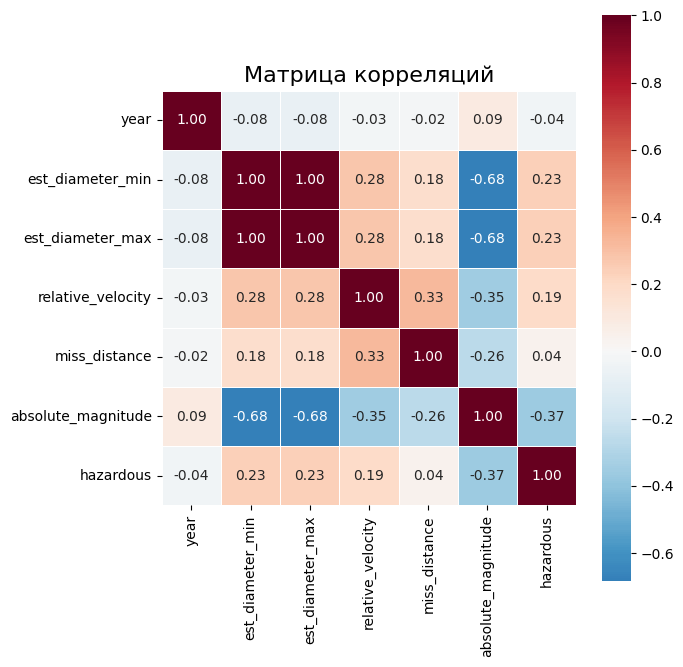

In [51]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = data[numeric_cols]

plt.figure(figsize=(7, 7))
correlation_matrix = df_numeric.corr(method='pearson')
sns.heatmap(correlation_matrix, 
            annot=True,  # показать значения
            fmt='.2f',   # формат чисел
            cmap='RdBu_r',  # цветовая схема
            center=0,    # центр в 0
            square=True,  # квадратные ячейки
            linewidths=0.5)  # линии между ячейками
plt.title('Матрица корреляций', fontsize=16)
plt.tight_layout()
plt.show()

Так как корреляция **est_diameter_min** и **est_diameter_max** равна 1, это по сути означает, что это один и тот же признак, поэтому целесообразно будет оставить только один из них. Если мы хотим понять, насколько опасен объект, нам важнее знать его максимально возможный размер, чтобы оценить потенциальную энергию удара, поэтому оставим только **est_diameter_max**, а **est_diameter_min** удалим

In [52]:
data = data.drop(columns='est_diameter_min')
data

,year,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,2011,0.035813,56014.078517,1.024333e+06,26.10,0
1,2020,0.068240,7864.348060,3.268186e+07,24.70,0
2,2016,0.124177,55257.544508,6.538636e+07,23.40,0
3,2013,0.043057,41531.404722,1.260796e+07,25.70,0
4,2016,0.311918,67639.394481,7.130590e+07,21.40,0
...,...,...,...,...,...,...
88529,2021,0.039268,23264.740825,1.635007e+06,25.90,0
88530,2018,0.247765,24802.519406,3.351901e+07,21.90,0
88531,2016,0.078350,116288.999548,5.471396e+07,24.40,0
88532,2014,0.098637,45763.317060,2.694877e+07,23.90,0


Снова выведем тепловую карту (Пирсон)

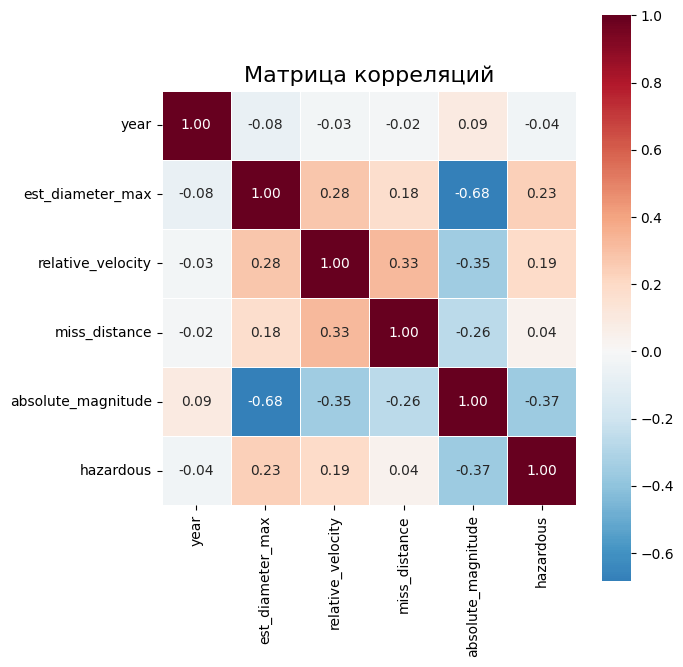

In [53]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = data[numeric_cols]

plt.figure(figsize=(7, 7))
correlation_matrix = df_numeric.corr(method='pearson')
sns.heatmap(correlation_matrix, 
            annot=True,  # показать значения
            fmt='.2f',   # формат чисел
            cmap='RdBu_r',  # цветовая схема
            center=0,    # центр в 0
            square=True,  # квадратные ячейки
            linewidths=0.5)  # линии между ячейками
plt.title('Матрица корреляций', fontsize=16)
plt.tight_layout()
plt.show()

У признака **absolute_magnitude** самая высокая корреляция с целевым признаком **hazardous**, за ним идет **est_diameter_max** с меньшей корреляцией, после них **relative_velocity** с еще меньшей корреляцией, при этом **miss_distance** почти не имеет корреляцию с целевым признаком, так же как и **year**

Для наглядности выведем тепловую карту (Спирмен)

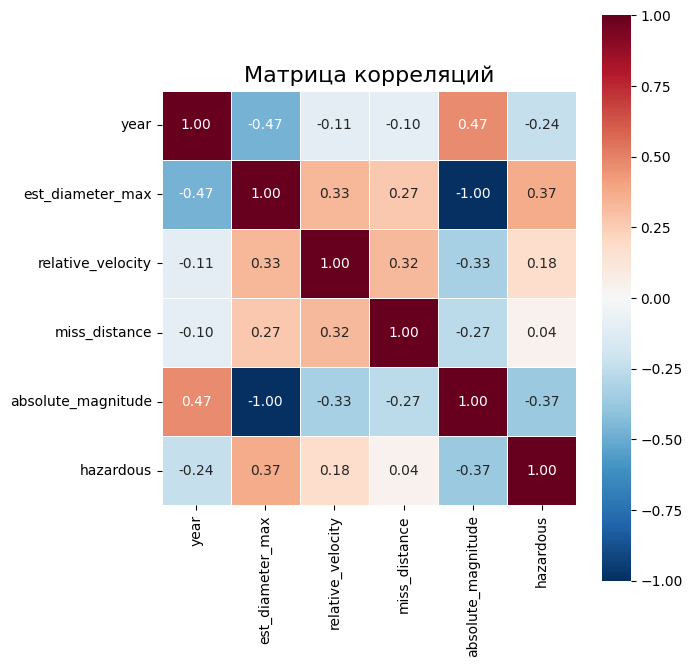

In [54]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = data[numeric_cols]

plt.figure(figsize=(7, 7))
correlation_matrix = df_numeric.corr(method='spearman')
sns.heatmap(correlation_matrix, 
            annot=True,  # показать значения
            fmt='.2f',   # формат чисел
            cmap='RdBu_r',  # цветовая схема
            center=0,    # центр в 0
            square=True,  # квадратные ячейки
            linewidths=0.5)  # линии между ячейками
plt.title('Матрица корреляций', fontsize=16)
plt.tight_layout()
plt.show()

Теперь можно наблюдать, что **year** все таки коррелирует с целевым признаком, **est_diameter_max** коррелирует сильнее.


Выводы:
- У **absolute_magnitude** и **est_diameter_max** самые высокие модули корреляции с **hazardous**
- **est_diameter_max** и **absolute_magnitude** один и тот же признак
-  Корреляция между **year** и **est_diameter_max** довольно большая

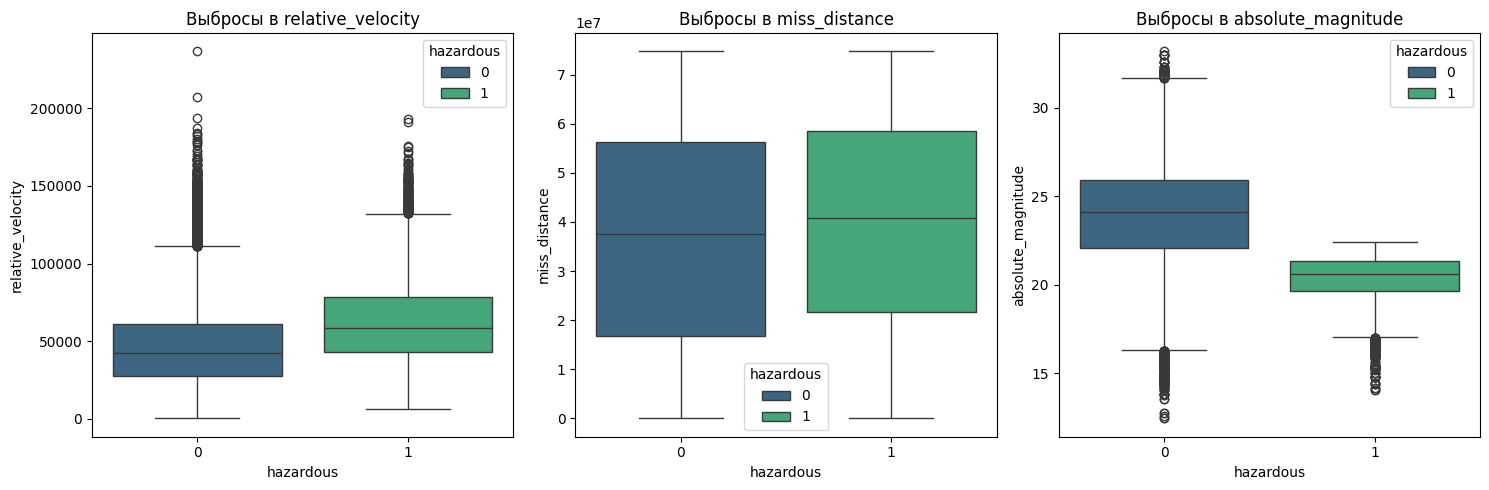

In [55]:
# Смотрим выбросы по скорости и дистанции
cols_to_check = ['relative_velocity', 'miss_distance', 'absolute_magnitude']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=data, y=col, x='hazardous', hue='hazardous', palette='viridis')
    plt.title(f'Выбросы в {col}')
plt.tight_layout()
plt.show()


Из ящиков с усами можно сделать следующие выводы:
- У **relative_velocity** большое количество выбросов в мажоритарном классе
- У **miss_distance** почти нет выбросов, что и следовало ожидать из гистрограммы
- У **absolute_magnitude** есть опасные маленькие астероиды и большие безопасные астероиды - выбросы, которые будут важны, так что их нельзя удалять.

Приравняем экстремальные выбросы к 99-ому процентилю у **relative_velocity**

In [56]:
limit = data['relative_velocity'].quantile(0.99)
data['relative_velocity'] = data['relative_velocity'].clip(upper=limit)

limit = data['relative_velocity'].quantile(0.99)
count_clipped = (data['relative_velocity'] > limit).sum()

count_clipped / len(data) * 100


1.0007454763141843

Примерно у 1% строк **relative_velocity** будет приравнен к 99-ому процентилю

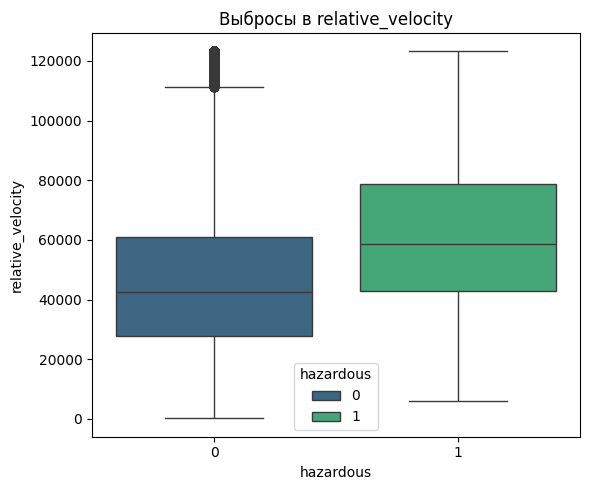

In [57]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=data, y='relative_velocity', x='hazardous', hue='hazardous', palette='viridis')
plt.title(f'Выбросы в relative_velocity')
plt.tight_layout()
plt.show()


In [58]:
data.to_csv('asteroids_cleaned.csv', index=False)

# Общие выводы:
Этот проект был направлен на изучение данных о характеристиках астероидов и определение ключевых факторов, влияющих на классификацию объекта как потенциально опасного. В ходе работы была проведена предобработка, заполнение пропусков и EDA.

Заполнение пропусков и работа с данными:
- Выявлена жесткая функциональная зависимость между абсолютной величиной и диаметром. Пропуски в магнитуде были восстановлены на основе максимального расчетного диаметра по формуле обратной логарифмической связи.
- Из столбца name был извлечен год обнаружения объекта для анализа временных зависимостей.
- Устранена избыточность данных: из двух идентичных признаков размера (min_diameter, max_diameter) для обучения был выбран один — max_diameter, также был убран id базы данных.

Обработка выбросов:
- Для устранения влияния экстремально высоких скоростей в мажоритарном классе применен метод клиппинга по 99-му перцентилю. Это позволило сгладить распределение скорости без удаления строк.
- Выбросы в классе опасных объектов были намеренно сохранены, так как они представляют собой редкие, но критически важные физические аномалии.

Изучение факторов опасности:
- Ключевыми факторами, влияющими на классификацию, оказались размер, магнитуда и скорость. Дистанция пролета в конкретный момент времени показала слабую связь с итоговой меткой опасности.
- Размер (Absolute Magnitude): Выявлен четкий порог опасности. Объекты с магнитудой выше определенного значения (мелкие объекты) практически никогда не признаются опасными. Визуализация в логарифмической шкале подтвердила бимодальность распределения.
- Скорость (Relative Velocity): Опасные объекты в среднем обладают более высокой скоростью. Скорость выступает допольнительным признаком указывающим на опасность для крупных тел.
- Дистанция (Miss Distance): Классификация объекта зависит скорее всего от его орбиты в целом, а не от дистанции, зафиксированного в датасете, так как корреляция с опасностью практически отсутвует.

Дисбаланс классов:
- В данных наблюдается умеренный дисбаланс (соотношение 1:9 в пользу неопасных объектов), что потребует отдельного внимания на следующих этапах.